In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import random
import os

In [2]:
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path("../data/filtered") / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)


Loaded: ..\data\filtered\youtube_static.csv


In [3]:
target = 'mac_dl_brate'
exclude = ['mac_dl_brate', 'ue_ident']
features = [col for col in df.columns if col not in exclude]

num_lags = 5
for lag in range(1, num_lags + 1):
    df[f'{target}_lag_{lag}'] = df[target].shift(lag)

df.dropna(inplace=True)

lag_features = [f'{target}_lag_{lag}' for lag in range(1, num_lags + 1)]
features += lag_features

input_steps = 5
prediction_horizon = 96

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print('Training Data',len(train_df))
print('Test Data',len(test_df))

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

train_features_scaled = scaler_features.fit_transform(train_df[features])
train_target_scaled = scaler_target.fit_transform(train_df[[target]])

test_features_scaled = scaler_features.transform(test_df[features])
test_target_scaled = scaler_target.transform(test_df[[target]])

def create_sequences(X_data, y_data, input_steps, prediction_horizon, original_index):
    X, y, dates = [], [], []
    for i in range(len(X_data) - input_steps - prediction_horizon + 1):
        X_seq = X_data[i:i+input_steps, :]  # Only features
        y_seq = y_data[i+input_steps:i+input_steps+prediction_horizon, 0]  # Only target
        X.append(X_seq.flatten())
        y.append(y_seq.flatten())
        dates.append(original_index[i+input_steps:i+input_steps+prediction_horizon])
    return np.array(X), np.array(y), dates

X_train_rf, y_train_rf, train_dates = create_sequences(
    train_features_scaled, train_target_scaled, input_steps, prediction_horizon, train_df.index)

X_test_rf, y_test_rf, test_dates = create_sequences(
    test_features_scaled, test_target_scaled, input_steps, prediction_horizon, test_df.index)

print('X_train_rf shape:', X_train_rf.shape)
print('y_train_rf shape:', y_train_rf.shape)
print('X_test_rf shape:', X_test_rf.shape)
print('y_test_rf shape:', y_test_rf.shape)


test_index_avg = [ts[len(ts) // 2] for ts in test_dates]

Training Data 26248
Test Data 6562


X_train_rf shape: (26148, 45)
y_train_rf shape: (26148, 96)
X_test_rf shape: (6462, 45)
y_test_rf shape: (6462, 96)


**XGBoost**

In [4]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

print('Training XGBoost Model')
xgbstart_time = time.time()
xgb_basemodel = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model = MultiOutputRegressor(xgb_basemodel)

xgb_model.fit(X_train_rf, y_train_rf)
xgbend_time = time.time()
xgbtraining_time = xgbend_time - xgbstart_time
print(f"XGBoost Training time: {xgbtraining_time:.2f} seconds")

Training XGBoost Model


XGBoost Training time: 206.34 seconds


In [5]:
xgbstart_time = time.time()
xgb_preds_scaled = xgb_model.predict(X_test_rf)
xgbend_time = time.time()
xgbinference_time = xgbend_time - xgbstart_time
xgbinference_time_per_sample = xgbinference_time / X_test_rf.shape[0]
print(f"XGBoost Inference time: {xgbinference_time:.2f} seconds")
print(f"XGBoost Inference time per sample: {xgbinference_time_per_sample:.6f} seconds")

xgb_rmse = np.sqrt(mean_squared_error(y_test_rf, xgb_preds_scaled))
xgb_mae = mean_absolute_error(y_test_rf, xgb_preds_scaled)

print(f'XGBoost - scaled RMSE: {xgb_rmse:.4f}')
print(f'XGBoost - scaled MAE: {xgb_mae:.4f}')

# Average for Visualization Purpose
xgb_pred_avg = np.mean(xgb_preds_scaled, axis=1, keepdims=True)
xgb_test_avg = np.mean(y_test_rf, axis=1, keepdims=True)

xgb_pred_reshaped = scaler_target.inverse_transform(xgb_pred_avg)
xgb_test_reshaped = scaler_target.inverse_transform(xgb_test_avg)

XGBoost Inference time: 1.77 seconds
XGBoost Inference time per sample: 0.000273 seconds
XGBoost - scaled RMSE: 0.0356
XGBoost - scaled MAE: 0.0232


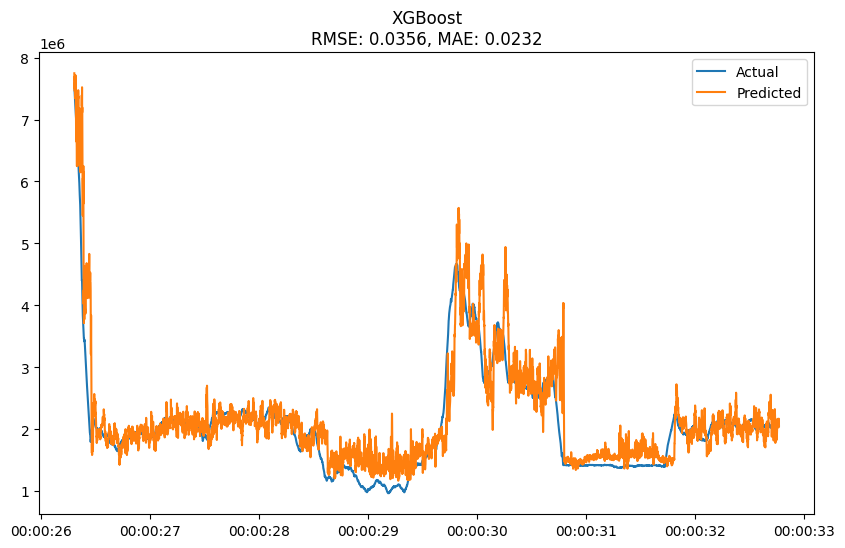

In [6]:
test_index_avg = pd.to_datetime(test_index_avg)

plt.figure(figsize=(10, 6))
plt.plot(test_index_avg, xgb_test_reshaped, label='Actual')
plt.plot(test_index_avg, xgb_pred_reshaped, label='Predicted')
plt.title(f'XGBoost\nRMSE: {xgb_rmse:.4f}, MAE: {xgb_mae:.4f}')
plt.legend()
plt.show()

In [7]:
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "XGB",
    "setting": "multivariate",
    "dataset": "youtube_static",
    "rmse": xgb_rmse,
    "mae": xgb_mae,
}])

metrics_file = results_dir / "xgb_multi_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\xgb_multi_metrics.csv
